# Result 2 — Biodiversity-loss evidence differs systematically across national income groups

**Question:** does the documented-threat composition of the biodiversity-loss evidence
differ with the income group of the country a study is about, and does any difference
survive holding region and publication period constant?


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "data_helpers").is_dir() and (candidate / "checklists").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the biodiversity repository root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
from data_helpers import results_config, visualization
from data_helpers.analysis import driver_composition
from data_helpers.prep import evidence_corpus_prep

In [4]:
visualization.apply_style()

RESULTS_CONFIG = results_config.load_results_config()
DRIVER_CONFIG = RESULTS_CONFIG["driver_composition"]
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
INCOME_CONFIG = RESULTS_CONFIG["world_bank_income"]
THREAT_ORDER, THREAT_COLORS, THREAT_DISPLAY_NAMES = results_config.threat_l0_display(
    RESULTS_CONFIG
)

INCOME_GROUPS = INCOME_CONFIG["group_order"]
TIER_ORDER = INCOME_CONFIG["tier_order"]
LOWER_TIER = set(INCOME_CONFIG["tiers"]["Lower-income tier"])
PERIOD_BINS, PERIOD_LABELS = driver_composition.publication_period_bins(
    DRIVER_CONFIG["publication_periods"]
)

MAPPING_PATH = PROJECT_ROOT / INCOME_CONFIG["world_bank_mapping"]
HISTORICAL_PATH = (
    PROJECT_ROOT
    / INCOME_CONFIG["world_bank_snapshot_curated"]
    / DRIVER_CONFIG["historical_classifications_file"]
)

# One output section holds this result: derived data, manuscript tables, figure.
OUTPUT_DIR = PROJECT_ROOT / DRIVER_CONFIG["output_directory"]
DATA_DIR = OUTPUT_DIR / DRIVER_CONFIG["data_subdirectory"]
TABLE_DIR = OUTPUT_DIR / DRIVER_CONFIG["table_subdirectory"]
FIGURE_DIR = OUTPUT_DIR / DRIVER_CONFIG["figure_subdirectory"]
for directory in (DATA_DIR, TABLE_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CORPUS_DIR = PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]

# Provenance: the complete set of inputs this result depends on.
print("Inputs")
for label, path in (
    ("evidence corpus  ", CORPUS_DIR),
    ("country mapping  ", MAPPING_PATH),
    ("income snapshot  ", HISTORICAL_PATH),
):
    status = "found" if path.exists() else "MISSING"
    print(f"  {label} {path.relative_to(PROJECT_ROOT)}  [{status}]")
missing = [
    path for path in (CORPUS_DIR, MAPPING_PATH, HISTORICAL_PATH) if not path.exists()
]
if missing:
    raise FileNotFoundError(
        "Run the data-processing prep notebooks first; missing: "
        f"{[str(path.relative_to(PROJECT_ROOT)) for path in missing]}"
    )
print(f"\nOutput section: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Inputs
  evidence corpus   notebooks/data_processing/outputs/04_biodiversity_evidence_corpus_prep  [found]
  country mapping   checklists/mappings/ipbes_world_bank_mapping.json  [found]
  income snapshot   data/world-bank/snapshots/wdi-2026-06-30/curated/classifications_historical.parquet  [found]

Output section: notebooks/results/outputs/02_income_composition


## 1. Evidence and historical income matching

Retain negative-direction observational records, expand them to unique
publication–country assignments, and attach the official World Bank classification in
force in the publication year rather than the current one, because a country's group
can change over the study period. The primary analysis keeps standard income groups and
complete publication years 2000–2025.

The audit table below carries the manuscript's article and country counts, and the
reclassified share reported in the Supplementary "Historical income matching" paragraph.

In [5]:
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(
    CORPUS_DIR
).load(columns=["UT", "publication_year", "s2_dir", "pred_study_design", "pred_countries", "pred_threat_l0"]).publications

evidence_preparation = driver_composition.prepare_historical_income_evidence(
    corpus_df,
    mapping_path=MAPPING_PATH,
    historical_path=HISTORICAL_PATH,
    income_groups=INCOME_GROUPS,
    direction=DRIVER_CONFIG["direction"],
    study_design=DRIVER_CONFIG["study_design"],
    start_year=DRIVER_CONFIG["primary_start_year"],
    end_year=DRIVER_CONFIG["primary_end_year"],
)
linked_country_df = evidence_preparation.primary

display(
    evidence_preparation.audit.style.format({"value": "{:,}"}).hide(axis="index")
)
print(f"Reclassified share: {evidence_preparation.reclassified_share:.1%}")

metric,value
Negative observational publications,"116,684"
World Bank-linked publication–country assignments,"107,929"
World Bank-linked unique publications,"97,430"
"Primary assignments: historical group, 2000–2025","104,556"
Primary unique publications,"94,443"
Countries in primary analysis,213
Assignments reclassified vs current group,"11,841"


Reclassified share: 11.0%


## 2. Threat composition and the extreme-group contrast

Panel **a** gives each income group's within-group composition; panel **b** gives the
high-income-minus-low-income difference in each category's share, in percentage points,
with 95% bootstrap intervals. Layers in panel a are ordered by the absolute size of that
contrast, largest at the bottom.

This is Figure `income_composition` in the manuscript, and the six rows printed below are
the contrasts quoted in the main text.

,unique_publications,represented_countries
historical_income_group,,
Low income,"4,973",69
Lower middle income,"15,981",99
Upper middle income,"30,808",89
High income,"45,554",85


,threat,low_income_share_pct,high_income_share_pct,high_minus_low_pp,bootstrap_ci_low,bootstrap_ci_high
11,Agriculture & Aquaculture,25.04,9.01,-16.03,-16.99,-14.95
10,Biological Resource Use,21.40,9.19,-12.21,-13.25,-11.17
0,Pollution,13.63,22.98,9.34,8.47,10.27
1,"Invasive & Other Problematic Species, Genes & ...",8.91,17.96,9.05,8.25,9.92
2,Climate Change & Severe Weather,8.98,14.95,5.96,5.19,6.71
3,Natural System Modifications,6.16,10.65,4.49,3.88,5.05


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/02_income_composition/figures/income_composition.pdf


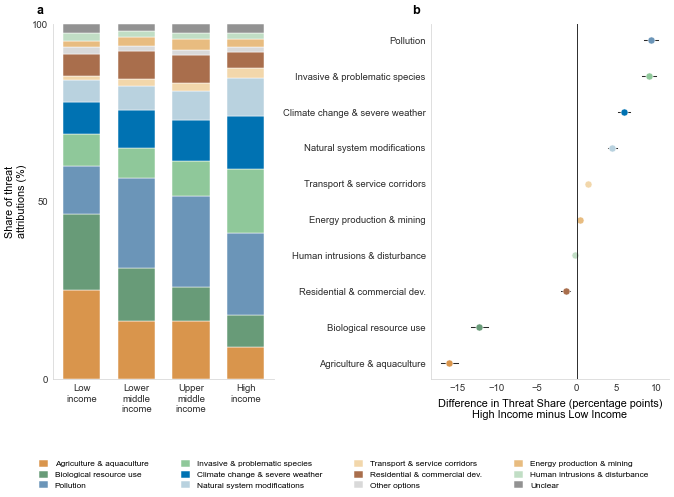

In [6]:
composition_analysis = driver_composition.analyze_income_composition(
    linked_country_df,
    threat_order=THREAT_ORDER,
    income_groups=INCOME_GROUPS,
    n_bootstrap=DRIVER_CONFIG["bootstrap_replicates"],
    seed=DRIVER_CONFIG["random_seed"],
)
observed_threat_order = composition_analysis.observed_threat_order

display(composition_analysis.group_counts.style.format("{:,}"))
display(
    composition_analysis.extreme_contrast.assign(
        absolute_difference=lambda df: df["high_minus_low_pp"].abs()
    )
    .nlargest(6, "absolute_difference")[
        [
            "threat",
            "low_income_share_pct",
            "high_income_share_pct",
            "high_minus_low_pp",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
        ]
    ]
    .round(2)
)

composition_figure = driver_composition.plot_income_composition(
    composition_analysis,
    income_groups=INCOME_GROUPS,
    threat_colors=THREAT_COLORS,
    threat_names=THREAT_DISPLAY_NAMES,
    contrast_excluded_threats=DRIVER_CONFIG["contrast_plot_excluded_threats"],
)
visualization.save_figure(
    composition_figure,
    FIGURE_DIR / DRIVER_CONFIG["composition_figure_filename"],
    formats=["pdf"],
    dpi=300,
    pad_inches=0.05,
)
plt.show()

## 3. Hold region and publication period constant

Income groups differ in which world regions and publication periods they draw on, so a
raw contrast could reflect the geography and timing of research rather than income. Pool
low and lower-middle into a lower-income tier and upper-middle and high into a
higher-income tier, then directly standardize both tiers to the same World Bank region ×
five-year-period distribution, using only strata present in both tiers. This is
descriptive adjustment, not a causal model, and pooling attenuates the contrast relative
to the extreme-group comparison in section 2.

The table below is Supplementary Table `income_standardized`.

In [7]:
standardization_analysis = driver_composition.analyze_standardized_tiers(
    linked_country_df,
    lower_tier_groups=LOWER_TIER,
    period_bins=PERIOD_BINS,
    period_labels=PERIOD_LABELS,
    threat_order=observed_threat_order,
    tier_order=TIER_ORDER,
    n_bootstrap=DRIVER_CONFIG["bootstrap_replicates"],
    seed=DRIVER_CONFIG["random_seed"] + 1,
)
standardization_meta = standardization_analysis.metadata

print(
    f"Shared regions: {standardization_meta['common_regions']}; "
    "shared region × period strata: "
    f"{standardization_meta['common_region_period_strata']}"
)
display(
    standardization_analysis.contrasts.loc[
        standardization_analysis.contrasts["threat"].isin(
            DRIVER_CONFIG["focus_threats"]
        ),
        [
            "threat",
            "raw_higher_minus_lower_pp",
            "region_standardized_higher_minus_lower_pp",
            "region_period_standardized_higher_minus_lower_pp",
            "joint_bootstrap_ci_low",
            "joint_bootstrap_ci_high",
        ],
    ].round(2)
)

Shared regions: 6; shared region × period strata: 28


,threat,raw_higher_minus_lower_pp,region_standardized_higher_minus_lower_pp,region_period_standardized_higher_minus_lower_pp,joint_bootstrap_ci_low,joint_bootstrap_ci_high
0,"Invasive & Other Problematic Species, Genes & ...",6.23,5.28,5.23,4.38,6.01
1,Climate Change & Severe Weather,3.23,3.91,2.96,1.11,3.90
2,Pollution,1.13,-0.06,1.54,0.21,2.81
3,Natural System Modifications,3.27,0.84,1.19,0.47,1.84
10,Biological Resource Use,-6.97,-5.56,-5.38,-6.35,-4.42
11,Agriculture & Aquaculture,-6.46,-5.98,-6.99,-7.93,-5.89


## 4. Robustness of the contrast

Recalculate the extreme-group contrast under five alternative specifications: all
negative study designs rather than observational only, current rather than historical
income classification, a shifted fiscal-year boundary, the partial 2026 year included,
and country-fractional weighting. Rank correlation and direction agreement near one mean
the reported pattern does not depend on these choices.

This is the Supplementary "Sensitivity analyses" paragraph.

In [8]:
sensitivity_df = driver_composition.build_sensitivity_summary(
    evidence_preparation,
    composition_analysis,
    income_groups=INCOME_GROUPS,
    start_year=DRIVER_CONFIG["primary_start_year"],
    end_year=DRIVER_CONFIG["primary_end_year"],
    partial_end_year=DRIVER_CONFIG["partial_end_year"],
)
display(sensitivity_df.round(3))

,comparison,rank_correlation,largest_change_pp,direction_agreement
0,All negative study designs,0.993,2.053,1.0
1,Current income classification,0.993,4.221,1.0
2,FY = publication year + 1,0.993,0.537,1.0
3,Include partial 2026,1.000,0.141,1.0
4,Country-fractional weighting,1.000,0.486,1.0


## 5. Export

The derived data and manuscript tables for this result: the classified assignments and
threat attributions as Parquet, then the classification audit, per-group article counts,
within-group composition, extreme-group bootstrap contrast, region–period standardized
tier contrast, and sensitivity summary as CSV.

In [9]:
written_paths = driver_composition.export_manuscript_tables(
    evidence_preparation,
    composition_analysis,
    standardization_analysis,
    sensitivity_df,
    data_directory=DATA_DIR,
    table_directory=TABLE_DIR,
    classified_assignments_file=DRIVER_CONFIG["classified_assignments_file"],
    threat_attributions_file=DRIVER_CONFIG["threat_attributions_file"],
)
figure_paths = sorted(FIGURE_DIR.glob("*.pdf"))
for path in [*written_paths, *figure_paths]:
    print(path.relative_to(PROJECT_ROOT))

notebooks/results/outputs/02_income_composition/data/historical_income_publication_country_assignments.parquet
notebooks/results/outputs/02_income_composition/data/historical_income_threat_attributions.parquet
notebooks/results/outputs/02_income_composition/csv/historical_income_classification_audit.csv
notebooks/results/outputs/02_income_composition/csv/income_group_article_counts.csv
notebooks/results/outputs/02_income_composition/csv/income_group_threat_composition.csv
notebooks/results/outputs/02_income_composition/csv/high_minus_low_income_bootstrap.csv
notebooks/results/outputs/02_income_composition/csv/region_period_standardized_tier_contrast.csv
notebooks/results/outputs/02_income_composition/csv/sensitivity_summary.csv
notebooks/results/outputs/02_income_composition/figures/income_composition.pdf
